# Домашнее задание 2

Продолжаем работу с датасетом lenta-ru-news. Задача — классификация текстов по топикам с использованием word2vec и предобученных эмбеддингов.

### Импорты и настройка среды

In [69]:
!pip -q install kagglehub pymorphy3 pymorphy2-dicts-ru razdel gensim navec nltk

In [70]:
import gc
import os
import re
import random

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer

from gensim.models import Word2Vec

from navec import Navec

import razdel
import pymorphy3
from functools import lru_cache
from tqdm import tqdm
import nltk
from nltk.corpus import stopwords

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

### Загрузка и очистка данных

Переиспользуем подготовку данных из ДЗ 1

In [71]:
!curl -sL -o /tmp/lenta-ru-news.csv.gz https://github.com/yutkin/Lenta.Ru-News-Dataset/releases/download/v1.0/lenta-ru-news.csv.gz

In [72]:
dataset_path = '/tmp/lenta-ru-news.csv.gz'
data = pd.read_csv(dataset_path)
df = data[['title', 'text', 'topic']].sample(n=100_000, random_state=RANDOM_STATE)

In [73]:
# Отфильтруем редкие классы и короткие тексты
topic_counts = df['topic'].value_counts()
valid_topics = topic_counts[topic_counts >= 300].index
df = df[df['topic'].isin(valid_topics)]

df['text_len'] = df['text'].str.len()
df = df[df['text_len'] >= 100]
df = df.drop(columns=['text_len'])

print(f"Классов: {df['topic'].nunique()}, Записей: {len(df)}")
df['topic'].value_counts()

Классов: 14, Записей: 99457


topic
Россия               21807
Мир                  18446
Экономика            10725
Спорт                 8631
Культура              7334
Бывший СССР           7093
Наука и техника       7084
Интернет и СМИ        6174
Из жизни              3710
Дом                   2891
Силовые структуры     2661
Ценности              1079
Бизнес                 967
Путешествия            855
Name: count, dtype: int64

### Предобработка и лемматизация

Переиспользуем пайплайн из ДЗ 1

In [74]:
morph = pymorphy3.MorphAnalyzer()
nltk.download('stopwords')
stop_words = set(stopwords.words('russian'))

URL_RE  = re.compile(r"(https?://\S+|www\.\S+)", re.IGNORECASE)
USER_RE = re.compile(r"@\w+")
NUM_RE  = re.compile(r"\b\d+([.,]\d+)?\b", re.UNICODE)
WS_RE   = re.compile(r"\s+", re.UNICODE)
WORD_RE = re.compile(r"^[a-zа-яё]+$", re.IGNORECASE)

def normalize_text(s):
    s = s.lower()
    s = URL_RE.sub(" __url__ ", s)
    s = USER_RE.sub(" __user__ ", s)
    s = NUM_RE.sub(" __num__ ", s)
    s = WS_RE.sub(" ", s).strip()
    return s

@lru_cache(maxsize=50_000)
def lemma_token_cached(token):
    if WORD_RE.match(token):
        return morph.parse(token)[0].normal_form
    return token

def preprocess_one_cached(s):
    s = normalize_text(s)
    tokens = [t.text for t in razdel.tokenize(s)]
    lemmas = [lemma_token_cached(t) for t in tokens]
    lemmas = [l for l in lemmas if l not in stop_words and len(l) > 1]
    return lemmas  # возвращаем список токенов (для w2v)

def preprocess_corpus(texts):
    return [preprocess_one_cached(str(t)) for t in tqdm(texts)]

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/yaroslav/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### 1. Разделение на train/val/test (60/20/20)

In [75]:
X = (df['title'] + ' ' + df['text']).values
y = df['topic'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
)
print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Train: 59674, Val: 19891, Test: 19892


In [76]:
# Лемматизация — возвращаем списки токенов (для w2v)
X_train_tokens = preprocess_corpus(X_train)
X_val_tokens = preprocess_corpus(X_val)
X_test_tokens = preprocess_corpus(X_test)

# Строковые версии для TF-IDF
X_train_str = [' '.join(t) for t in X_train_tokens]
X_val_str = [' '.join(t) for t in X_val_tokens]
X_test_str = [' '.join(t) for t in X_test_tokens]

100%|██████████████████████████████████████████████████████████████████████████████| 19892/19892 [00:16<00:00, 1204.61it/s]


### 2. Обучение word2vec-эмбеддингов

In [77]:
# Обоснование выбора гиперпараметров:
# Skip-gram: стандарт индустрии + лучше работает с редкими словами
# vector_size=300: стандартная размерность, совпадает с navec, даст честное сравнение, данных у нас достаточно
# window=3: для новостного текста контекст кажется плотный и 3 должно быть оптимальным выбором
# min_count=5: слова с <5 вхождений не наберут достаточно контекста для построения вектора
w2v_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=300,
    window=3,
    min_count=5,
    sg=1,
    epochs=10,
    workers=8,
    seed=RANDOM_STATE,
)

print(f"Словарь: {len(w2v_model.wv)} слов, размерность: {w2v_model.wv.vector_size}")

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

Словарь: 51398 слов, размерность: 300


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [78]:
# Проверяем, может ли модель выделить "лишнее" слово из группы семантически связанных
test_groups = [
    ["футбол", "хоккей", "баскетбол", "экономика"],
    ["москва", "петербург", "новосибирск", "доллар"],
    ["президент", "министр", "депутат", "самолёт"],
    ["рубль", "доллар", "евро", "стадион"],
]

for group in test_groups:
    try:
        odd = w2v_model.wv.doesnt_match(group)
        print(f"{group} → лишнее: {odd}")
    except KeyError as e:
        print(f"{group} → слово не найдено: {e}")

['футбол', 'хоккей', 'баскетбол', 'экономика'] → лишнее: экономика
['москва', 'петербург', 'новосибирск', 'доллар'] → лишнее: доллар
['президент', 'министр', 'депутат', 'самолёт'] → лишнее: самолёт
['рубль', 'доллар', 'евро', 'стадион'] → лишнее: стадион


In [79]:
# Проверяем, какие слова модель считает семантически близкими
test_words = ["россия", "экономика", "футбол", "суд", "интернет"]

for word in test_words:
    try:
        similar = w2v_model.wv.most_similar(word, topn=5)
        print(f"\n'{word}' → {[(w, round(s, 3)) for w, s in similar]}")
    except KeyError:
        print(f"\n'{word}' → не найдено в словаре")


'россия' → [('рф', 0.645), ('барнашов', 0.512), ('государств-участников', 0.507), ('российский', 0.504), ('куракина', 0.499)]

'экономика' → [('ввп', 0.614), ('рубиня', 0.578), ('экономический', 0.568), ('рецессия', 0.564), ('макроэкономический', 0.557)]

'футбол' → [('баскетбол', 0.593), ('футбольный', 0.584), ('суперкубок', 0.554), ('премьер-лига', 0.552), ('мундиаль', 0.55)]

'суд' → [('райсуд', 0.667), ('арбитраж', 0.615), ('горсуд', 0.608), ('облсуд', 0.596), ('мособлсуд', 0.593)]

'интернет' → [('широкополосный', 0.568), ('торрент', 0.551), ('торрент-трекеров', 0.541), ('сеть', 0.531), ('телефония', 0.526)]


### 3. Загрузка предобученных эмбеддингов (navec + rusvectores)

In [80]:
# Загрузка navec — предобученные эмбеддинги, пак news (обучен на новостном корпусе, 300d)
!curl -sL -o /tmp/navec_news_v1_1B_250K_300d_100q.tar https://storage.yandexcloud.net/natasha-navec/packs/navec_news_v1_1B_250K_300d_100q.tar

navec_emb = Navec.load('/tmp/navec_news_v1_1B_250K_300d_100q.tar')
print(f"Navec: {len(navec_emb.vocab.words)} слов, размерность: {navec_emb.pq.dim}")

Navec: 250002 слов, размерность: 300


In [81]:
# Загрузка RusVectores 
from gensim.models import KeyedVectors
import zipfile

!curl -sL -o /tmp/araneum_none_fasttextcbow_300_5_2018.tgz http://vectors.nlpl.eu/repository/20/180.zip

with zipfile.ZipFile('/tmp/araneum_none_fasttextcbow_300_5_2018.tgz', 'r') as z:
    z.extractall('/tmp/rusvectores/')

rusvec_emb = KeyedVectors.load_word2vec_format('/tmp/rusvectores/model.bin', binary=True)
print(f"RusVectores: {len(rusvec_emb)} слов, размерность: {rusvec_emb.vector_size}")

RusVectores: 189193 слов, размерность: 300


### 4. LogisticRegression с тремя наборами эмбеддингов

Для каждого набора эмбеддингов: усредняем вектора слов текста -> получаем вектор документа -> обучаем LogisticRegression.

In [82]:
def text_to_vec(tokens, model, vector_size):
    vectors = [model[w] for w in tokens if w in model]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

def vectorize_corpus(token_lists, model, vector_size):
    return np.array([text_to_vec(t, model, vector_size) for t in tqdm(token_lists)])

In [83]:
# Векторизация через собственные w2v эмбеддинги
print("W2V:")
X_train_w2v = vectorize_corpus(X_train_tokens, w2v_model.wv, 300)
X_val_w2v = vectorize_corpus(X_val_tokens, w2v_model.wv, 300)
X_test_w2v = vectorize_corpus(X_test_tokens, w2v_model.wv, 300)

W2V:


100%|█████████████████████████████████████████████████████████████████████████████| 19892/19892 [00:01<00:00, 15776.32it/s]


In [84]:
# Векторизация через navec
print("Navec:")
navec_dim = navec_emb.pq.dim
X_train_navec = vectorize_corpus(X_train_tokens, navec_emb, navec_dim)
X_val_navec = vectorize_corpus(X_val_tokens, navec_emb, navec_dim)
X_test_navec = vectorize_corpus(X_test_tokens, navec_emb, navec_dim)

Navec:


100%|██████████████████████████████████████████████████████████████████████████████| 19892/19892 [00:07<00:00, 2635.05it/s]


In [ ]:
# Векторизация через rusvectores
sample_keys = list(rusvec_emb.key_to_index.keys())[:5]
print("Примеры ключей rusvectores:", sample_keys)

has_pos = '_' in sample_keys[0]
print(f"POS-теги в ключах: {has_pos}")

if has_pos:
    class RusVecWrapper:
        def __init__(self, kv):
            self.kv = kv
            self._pos_tags = ['_NOUN', '_VERB', '_ADJ', '_ADV', '_PROPN', '_X']
        def __contains__(self, word):
            return any(f"{word}{pos}" in self.kv for pos in self._pos_tags)
        def __getitem__(self, word):
            for pos in self._pos_tags:
                key = f"{word}{pos}"
                if key in self.kv:
                    return self.kv[key]
            raise KeyError(word)
    rusvec_lookup = RusVecWrapper(rusvec_emb)
else:
    rusvec_lookup = rusvec_emb

print("\nRusVectores:")
rusvec_dim = rusvec_emb.vector_size
X_train_rusvec = vectorize_corpus(X_train_tokens, rusvec_lookup, rusvec_dim)
X_val_rusvec = vectorize_corpus(X_val_tokens, rusvec_lookup, rusvec_dim)
X_test_rusvec = vectorize_corpus(X_test_tokens, rusvec_lookup, rusvec_dim)

Примеры ключей rusvectores: ['так_ADV', 'быть_VERB', 'мочь_VERB', 'год_NOUN', 'человек_NOUN']
POS-теги в ключах: True

RusVectores:


100%|██████████████████████████████████████████████████████████████████████████████| 19892/19892 [00:02<00:00, 6970.76it/s]


In [86]:
# Обучение LogisticRegression на каждом наборе эмбеддингов, сравнение на val
results = {}

for name, X_tr, X_v in [
    ("w2v", X_train_w2v, X_val_w2v),
    ("navec", X_train_navec, X_val_navec),
    ("rusvectores", X_train_rusvec, X_val_rusvec),
]:
    clf = LogisticRegression(
        solver="saga", max_iter=2000, class_weight='balanced',
        C=2.0, random_state=RANDOM_STATE
    )
    clf.fit(X_tr, y_train)
    val_acc = accuracy_score(y_val, clf.predict(X_v))
    results[name] = {"clf": clf, "val_acc": val_acc}
    print(f"\n{'='*60}")
    print(f"{name}: val accuracy = {val_acc:.4f}")
    print(classification_report(y_val, clf.predict(X_v)))

/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



w2v: val accuracy = 0.7611
                   precision    recall  f1-score   support

           Бизнес       0.22      0.68      0.33       194
      Бывший СССР       0.74      0.86      0.80      1418
              Дом       0.69      0.88      0.78       578
         Из жизни       0.52      0.72      0.60       742
   Интернет и СМИ       0.70      0.74      0.72      1235
         Культура       0.87      0.85      0.86      1467
              Мир       0.84      0.75      0.79      3689
  Наука и техника       0.83      0.78      0.81      1417
      Путешествия       0.42      0.84      0.56       171
           Россия       0.87      0.62      0.73      4361
Силовые структуры       0.33      0.71      0.45       532
            Спорт       0.96      0.96      0.96      1726
         Ценности       0.72      0.86      0.78       216
        Экономика       0.86      0.75      0.80      2145

         accuracy                           0.76     19891
        macro avg       0.

/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



navec: val accuracy = 0.7426
                   precision    recall  f1-score   support

           Бизнес       0.20      0.67      0.31       194
      Бывший СССР       0.73      0.86      0.79      1418
              Дом       0.68      0.86      0.76       578
         Из жизни       0.47      0.72      0.57       742
   Интернет и СМИ       0.70      0.73      0.71      1235
         Культура       0.87      0.85      0.86      1467
              Мир       0.83      0.73      0.77      3689
  Наука и техника       0.82      0.78      0.80      1417
      Путешествия       0.38      0.82      0.52       171
           Россия       0.85      0.59      0.70      4361
Силовые структуры       0.30      0.69      0.42       532
            Спорт       0.96      0.96      0.96      1726
         Ценности       0.69      0.84      0.76       216
        Экономика       0.85      0.71      0.77      2145

         accuracy                           0.74     19891
        macro avg       

/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


По результату, выходит так, что наш w2v > navec > rusvectores

Впринципе, это объяснимо:
1. Мы обучали свой w2v непосредственно на нашем каркасе
2. Домен новостных данных может влиять на качество (у rusvectores не удалось найти готовых эмбеддингов по новостным данным)
3. К готовым эмбеддингам лемматизация не применена, вероятно некоторого кол-ва слов не оказалось в выборке

### 5. Взвешивание через TF-IDF 

In [87]:
# Обучаем TfidfVectorizer на train корпусе, извлекаем IDF-веса для каждого слова
tfidf = TfidfVectorizer(
    # min_df=5 
    max_df=0.5
)
tfidf.fit(X_train_str)
word2idf = dict(zip(tfidf.get_feature_names_out(), tfidf.idf_))
print(f"Словарь TF-IDF: {len(word2idf)} слов")

Словарь TF-IDF: 168072 слов


In [88]:
# Взвешенное усреднение: вес каждого слова = его IDF
def text_to_vec_tfidf(tokens, model, vector_size, word2idf):
    vectors, weights = [], []
    for w in tokens:
        if w in model and w in word2idf:
            vectors.append(model[w])
            weights.append(word2idf[w])
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.average(vectors, axis=0, weights=weights)

def vectorize_corpus_tfidf(token_lists, model, vector_size, word2idf):
    return np.array([text_to_vec_tfidf(t, model, vector_size, word2idf) for t in tqdm(token_lists)])

In [89]:
# Берём лучший набор эмбеддингов (w2v) и применяем TF-IDF взвешивание
best_name = max(results, key=lambda k: results[k]["val_acc"])
print(f"Лучший набор эмбеддингов: {best_name}")

X_train_w2v_tfidf = vectorize_corpus_tfidf(X_train_tokens, w2v_model.wv, 300, word2idf)
X_val_w2v_tfidf = vectorize_corpus_tfidf(X_val_tokens, w2v_model.wv, 300, word2idf)
X_test_w2v_tfidf = vectorize_corpus_tfidf(X_test_tokens, w2v_model.wv, 300, word2idf)

clf_tfidf = LogisticRegression(
    solver="saga", max_iter=2000, class_weight='balanced',
    C=2.0, random_state=RANDOM_STATE
)
clf_tfidf.fit(X_train_w2v_tfidf, y_train)

val_acc_tfidf = accuracy_score(y_val, clf_tfidf.predict(X_val_w2v_tfidf))
results["w2v + tfidf"] = {"clf": clf_tfidf, "val_acc": val_acc_tfidf}

print(f"\nw2v + TF-IDF взвешивание: val accuracy = {val_acc_tfidf:.4f}")
print(classification_report(y_val, clf_tfidf.predict(X_val_w2v_tfidf)))

Лучший набор эмбеддингов: w2v


100%|██████████████████████████████████████████████████████████████████████████████| 19892/19892 [00:02<00:00, 9229.74it/s]



w2v + TF-IDF взвешивание: val accuracy = 0.7564
                   precision    recall  f1-score   support

           Бизнес       0.21      0.63      0.32       194
      Бывший СССР       0.74      0.86      0.80      1418
              Дом       0.69      0.88      0.78       578
         Из жизни       0.51      0.72      0.60       742
   Интернет и СМИ       0.68      0.74      0.71      1235
         Культура       0.87      0.85      0.86      1467
              Мир       0.84      0.75      0.79      3689
  Наука и техника       0.82      0.78      0.80      1417
      Путешествия       0.42      0.82      0.56       171
           Россия       0.86      0.61      0.72      4361
Силовые структуры       0.31      0.70      0.43       532
            Спорт       0.96      0.96      0.96      1726
         Ценности       0.74      0.86      0.80       216
        Экономика       0.85      0.74      0.79      2145

         accuracy                           0.76     19891
     

TF-IDF не дал результатов лучше, даже после анализа IDF и попыток фильтрации, разных параметров модели и проверки несколько гипотез

Я это связываю с тем, что основная часть ошибок модели лежит в семантически близких классах - "Бизнес"+"Экономика", "Силовые структуры"+"Россия" и тп. TF-IDF на них картину глобально изменить не сможет - они находятся примерно в одном пространстве. 

Можем через TSNE посмотреть и увидеть "кашу" из политико-экономических топиков, которые сложно развести без доп. анализа или других методов решения

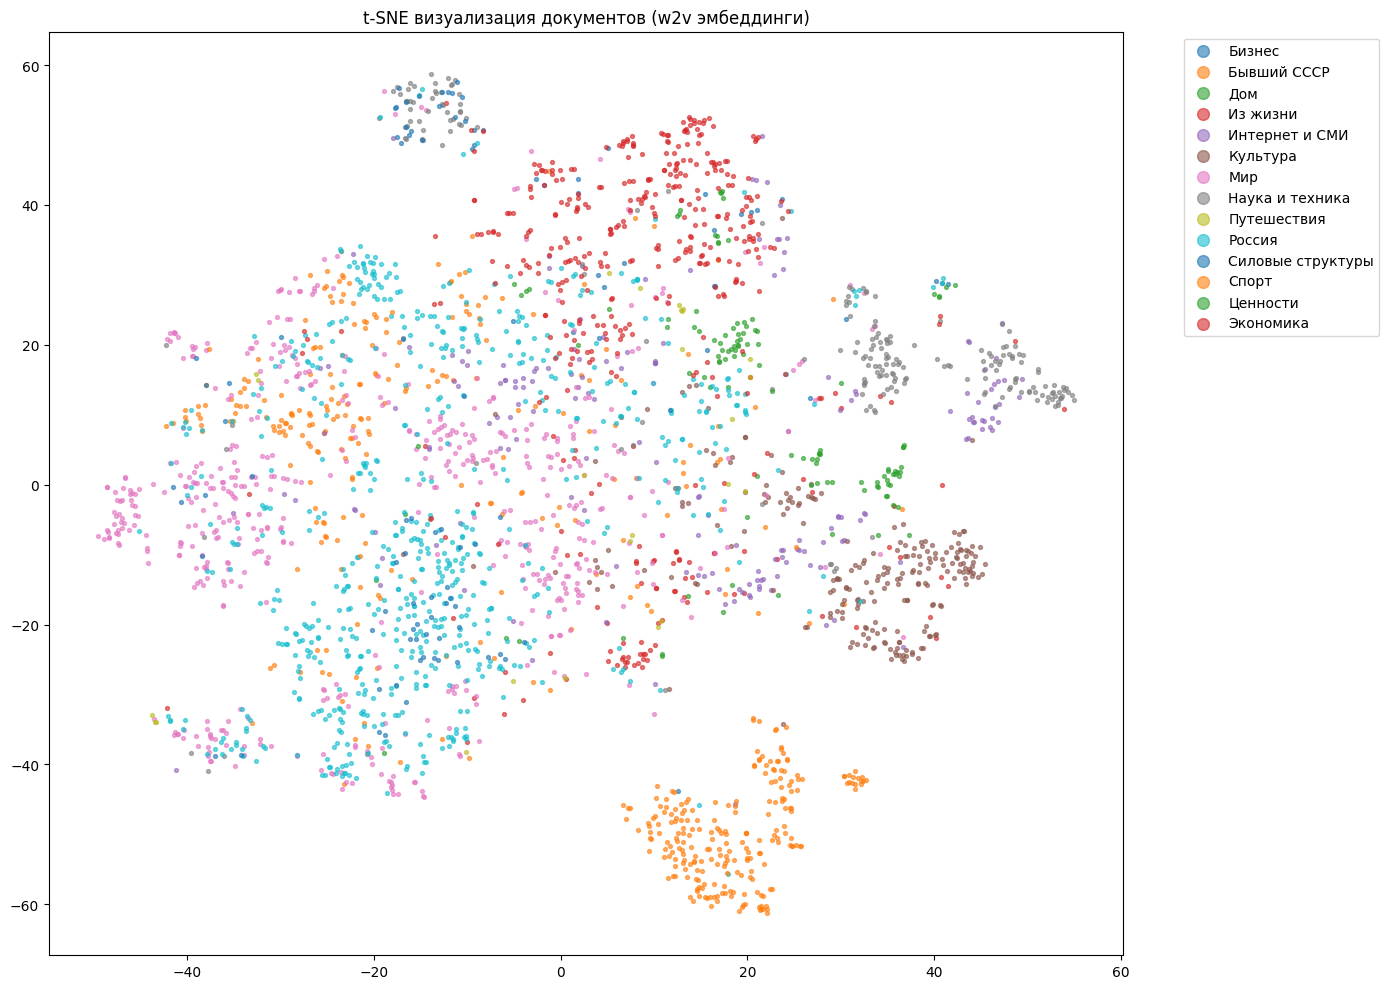

In [ ]:
from sklearn.manifold import TSNE

# Берём подвыборку для скорости
n_sample = 3000
idx = np.random.choice(len(X_val_w2v), n_sample, replace=False)
X_sample = X_val_w2v[idx]
y_sample = np.array(y_val)[idx]

tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30)
X_2d = tsne.fit_transform(X_sample)

plt.figure(figsize=(14, 10))
topics = np.unique(y_sample)
for topic in topics:
    mask = y_sample == topic
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], label=topic, s=8, alpha=0.6)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=3)
plt.title("t-SNE визуализация документов (w2v эмбеддинги)")
plt.tight_layout()
plt.show()

### 6. Финальное сравнение и выводы

In [91]:
# Финальное сравнение всех моделей на тестовой выборке
test_data = {
    "w2v": (X_test_w2v, results["w2v"]["clf"]),
    "navec": (X_test_navec, results["navec"]["clf"]),
    "rusvectores": (X_test_rusvec, results["rusvectores"]["clf"]),
    "w2v + tfidf": (X_test_w2v_tfidf, results["w2v + tfidf"]["clf"]),
}

test_results = {}
for name, (X_te, clf) in test_data.items():
    test_acc = accuracy_score(y_test, clf.predict(X_te))
    test_results[name] = test_acc
    print(f"\n{name}: test accuracy = {test_acc:.4f}")
    print(classification_report(y_test, clf.predict(X_te)))

# Сводная таблица
print("\n" + "="*60)
print("СВОДКА")
print("="*60)
summary = pd.DataFrame({
    "Model": test_results.keys(),
    "Val Accuracy": [results[n]["val_acc"] for n in test_results],
    "Test Accuracy": test_results.values(),
}).sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
print(summary.to_string(index=False))


w2v: test accuracy = 0.7600
                   precision    recall  f1-score   support

           Бизнес       0.22      0.68      0.34       193
      Бывший СССР       0.75      0.85      0.80      1419
              Дом       0.73      0.86      0.79       578
         Из жизни       0.52      0.71      0.60       742
   Интернет и СМИ       0.70      0.74      0.72      1235
         Культура       0.88      0.87      0.87      1467
              Мир       0.84      0.75      0.79      3689
  Наука и техника       0.80      0.77      0.79      1417
      Путешествия       0.41      0.82      0.55       171
           Россия       0.87      0.63      0.73      4362
Силовые структуры       0.32      0.73      0.44       532
            Спорт       0.97      0.96      0.97      1726
         Ценности       0.69      0.84      0.76       216
        Экономика       0.86      0.74      0.80      2145

         accuracy                           0.76     19892
        macro avg       0

Лучшая модель: w2v


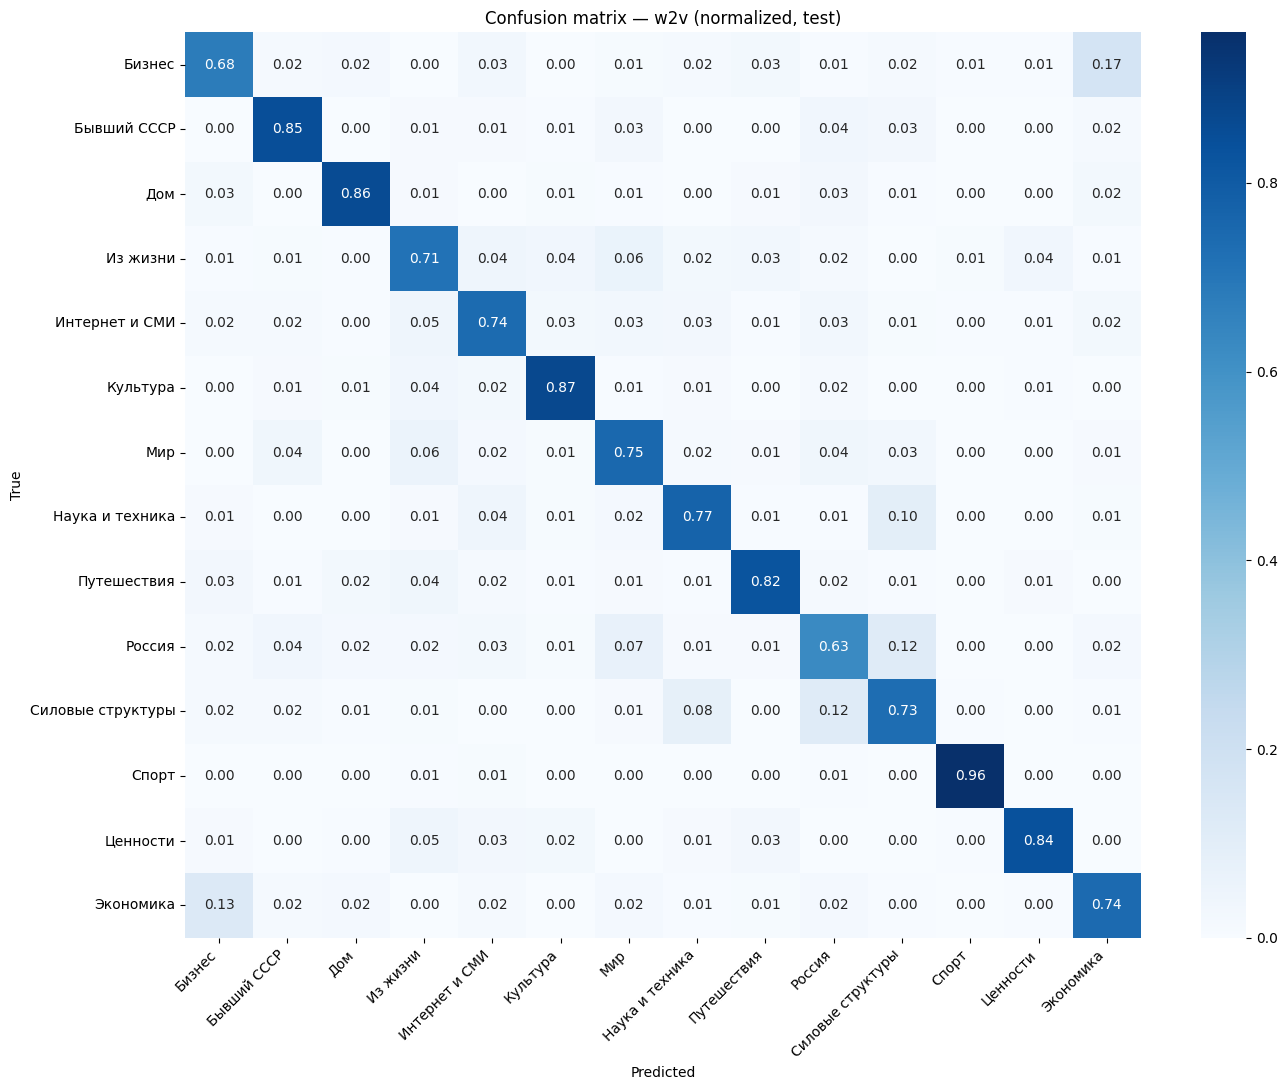

In [92]:
# Confusion matrix для лучшей модели
best_test_name = max(test_results, key=test_results.get)
best_clf = test_data[best_test_name][1]
best_X_test = test_data[best_test_name][0]
best_pred = best_clf.predict(best_X_test)

print(f"Лучшая модель: {best_test_name}")

cm = confusion_matrix(y_test, best_pred, labels=best_clf.classes_)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(14, 11))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=best_clf.classes_,
            yticklabels=best_clf.classes_)
plt.title(f"Confusion matrix — {best_test_name} (normalized, test)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Основной вывод по работе: эмбеддинги не решили проблему семантической близости классов - ошибка все так же сохраняется. Классы, которые не близки к других, не попадают в политико-экономическую кашу и модель показывает хорошие метрики на них (например "Спорт" и "Культура").

Вероятно, тут сможет помочь архитектура, которая учитывает порядок слов (RNN / LSTM) или другие методы работы с документами, не просто усредненный вектор, который дает посредственное представление о содержимом.